# Pryor b = 14 nm benchmark, with corrected strain and piezoelectricity

Same figures as `pryor_benchmark.ipynb`, recomputed with the physics that notebook was missing:

| | `pryor_benchmark.ipynb` | here |
|---|---|---|
| strain | Davies uniform $\mathrm{Tr}\,\varepsilon$, zero shear | full tensor, anisotropic cubic elasticity |
| hydrostatic magnitude | constrained strain (1.165x too large) | elastic strain |
| shear / Bir-Pikus | absent | $Q_\varepsilon$, $R_\varepsilon$, $S_\varepsilon$ |
| piezoelectricity | absent | first-order, from the shear components |
| grid | `np.arange`, h = 0.7 | `centered_axis`, h = 0.5, symmetry asserted |

The old notebook made a specific prediction it could not test. Its cell 8 printed:

> *"$p_x/p_y$ splitting ... must be ~0: the C4 symmetry of the square island is only broken by
> the piezoelectric term, which we omit and which splits Pryor's pair by 2-6 meV"*

That is now testable, and it is the headline result below.

A note on the grid, because it changes the numbers: at h = 0.7 the {101} facets $|x| = 7-z$ land
exactly on grid coordinates, and `np.arange` builds an axis asymmetric at the 1e-14 level. The
tie-break then flips 180 of 1140 dot voxels, leaving the pyramid lopsided and 14% undersized.
Any $p_x/p_y$ splitting measured on it is partly the grid. h = 0.5 with `centered_axis` is exact
to 0.1% and mirror-symmetric to the voxel, and the asserts below enforce it.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import qdsolver_core as qd
import strain_fourier as sf
import piezoelectric as pz
import pryor1998 as pr
import eigensolvers as eig

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

InAs, GaAs = pr.PRYOR_TABLE_I['InAs'], pr.PRYOR_TABLE_I['GaAs']
GAAS_CB = pr.BENCHMARK_B14['GaAs_CB_edge']
print('ready')

ready


## 1. Geometry, strain and the piezoelectric potential

`strain_fourier.solve_strain` gives the whole tensor by Fourier continuum elasticity (Andreev,
Downes, Faux & O'Reilly, *J. Appl. Phys.* **86**, 297 (1999)), keeping the anisotropic cubic
$C_{11}/C_{12}/C_{44}$. The shear components then drive the piezoelectric polarization
$P_i = 2e_{14}\varepsilon_{jk}$.

In [2]:
base, h, pad = 14.0, 0.5, 10.0

nx = int(round(2 * (base / 2 + pad) / h)) // 2 * 2 + 1
kz0 = int(round(pad / h))
nz = kz0 + int(round((base / 2 + pad) / h)) + 1
cx = qd.centered_axis(nx, h)
cz = (np.arange(nz) - kz0) * h
X, Y, Z = np.meshgrid(cx, cx, cz, indexing='ij')
inside = qd.pyramid_mask(X, Y, Z, base)

# guards -- an asymmetric grid fakes the very splitting this notebook measures
assert qd.mirror_asymmetry(inside, 0) == 0 and qd.mirror_asymmetry(inside, 1) == 0
exact_vol = base**2 * (base / 2) / 3

eps_star = qd.eigenstrain(InAs['a0'], GaAs['a0'])
nu = qd.voigt_poisson_ratio(GaAs['C11'], GaAs['C12'], GaAs['C44'])
strain = sf.solve_strain(inside, eps_star, GaAs['C11'], GaAs['C12'], GaAs['C44'], h)
trace_strain = strain.trace
phi = pz.potential(strain, np.where(inside, InAs['e14'], GaAs['e14']), GaAs['eps_R'], h)

# what the old notebook used, for comparison
trace_old, trace_old_in = qd.trace_strain_from_mask(inside, eps_star, nu)

print(f"grid {X.shape} = {X.size:,} points, h = {h} nm")
print(f"volume error {qd.mask_volume_error(inside, h, exact_vol):+.4f}, "
      f"mirror-x flips {qd.mirror_asymmetry(inside, 0)}")
print(f"lattice mismatch {eps_star*100:+.2f}%   clamping residual "
      f"{sf.padding_report(strain, inside):.4f}")

d, dr = strain.at(inside), strain.at_rms(inside)
print(f"\nTr(eps) in the dot  {d['exx']+d['eyy']+d['ezz']:+.5f}   "
      f"(old model: {trace_old_in:+.5f}, uniform)")
print(f"biaxial             {d['exx']+d['eyy']-2*d['ezz']:+.5f}   "
      f"(old model: 0 -- no shear at all)")
print(f"rms shear  exy {dr['exy']:.5f}  eyz {dr['eyz']:.5f}  ezx {dr['ezx']:.5f}")
print(f"\npiezo potential {phi.min()*1e3:+.1f} .. {phi.max()*1e3:+.1f} meV globally, "
      f"{phi[inside].min()*1e3:+.1f} .. {phi[inside].max()*1e3:+.1f} meV in the dot")
print(f"C4 antisymmetry error {pz.c4_antisymmetry_error(phi):.1e} (exact zero required)")

Ec_dot = InAs['E_vbo'] + InAs['Eg'] + InAs['a_c'] * trace_strain
Ev_dot = InAs['E_vbo'] - InAs['a_v'] * trace_strain
print(f"\nconduction well {(GAAS_CB-Ec_dot[inside].mean())*1e3:.1f} meV mean, TAPERED")
print(f"                Pryor: 400 meV at the base tapering to 270 meV at the tip")

grid (69, 69, 55) = 261,855 points, h = 0.5 nm
volume error -0.0013, mirror-x flips 0
lattice mismatch -6.69%   clamping residual 0.0305

Tr(eps) in the dot  -0.08884   (old model: -0.10795, uniform)
biaxial             -0.10275   (old model: 0 -- no shear at all)
rms shear  exy 0.00687  eyz 0.01175  ezx 0.01175

piezo potential -55.8 .. +55.8 meV globally, -22.4 .. +22.4 meV in the dot
C4 antisymmetry error 8.7e-16 (exact zero required)

conduction well 424.4 meV mean, TAPERED
                Pryor: 400 meV at the base tapering to 270 meV at the tip


## 2. One-band states, with and without the piezoelectric field

The electron charge is $-e$, so its potential energy is $-e\phi$; the hole gets $+e\phi$.

In [3]:
results = {}
for case in ('unstrained', 'strain_averaged'):
    V_e, V_h, m_e, m_h = pr.band_edge_fields(inside, trace_strain, case)
    for piezo in (False, True):
        V = V_e - phi if piezo else V_e
        t0 = time.time()
        E, psi, _ = eig.solve_lowest(qd.build_hamiltonian(m_e, V, h), k=6,
                                     tol=1e-8, maxiter=8000)
        results[(case, piezo)] = dict(E=E, psi=psi, V_e=V, V_h=V_h, m_e=m_e, m_h=m_h)
        n_bound = int(np.sum(E < GAAS_CB))
        print(f"{case:16s} piezo={str(piezo):5s} "
              f"m_dot = {pr.PRYOR_ELECTRON_MASSES[case]['dot']:.3f} m0  "
              f"({time.time()-t0:.0f}s)")
        print(f"   E (eV) = {np.round(E, 4)}")
        print(f"   bound: {n_bound};  E0 = {E[0]:.4f} eV "
              f"({(GAAS_CB-E[0])*1e3:.1f} meV below the GaAs CB edge);  "
              f"p-splitting {abs(E[2]-E[1])*1e3:.3f} meV")

  LOBPCG: 215.9s, 1373 iterations, block 9, max residual on the wanted 6: 3.80e-09 eV; gap to next Ritz value 5.07 meV
unstrained       piezo=False m_dot = 0.023 m0  (216s)
   E (eV) = [1.3682 1.5125 1.5125 1.56   1.567  1.5715]
   bound: 3;  E0 = 1.3682 eV (150.8 meV below the GaAs CB edge);  p-splitting 0.000 meV


  LOBPCG: 290.6s, 1650 iterations, block 9, max residual on the wanted 6: 7.10e-10 eV; gap to next Ritz value 6.71 meV
unstrained       piezo=True  m_dot = 0.023 m0  (291s)
   E (eV) = [1.368  1.51   1.5126 1.5544 1.5611 1.5668]
   bound: 3;  E0 = 1.3680 eV (151.0 meV below the GaAs CB edge);  p-splitting 2.564 meV


  LOBPCG: 1708.0s, 1071 iterations, block 9, max residual on the wanted 6: 1.18e-06 eV; gap to next Ritz value 11.19 meV
strain_averaged  piezo=False m_dot = 0.040 m0  (1708s)
   E (eV) = [1.3347 1.4627 1.4627 1.5471 1.55   1.5595]
   bound: 3;  E0 = 1.3347 eV (184.3 meV below the GaAs CB edge);  p-splitting 0.000 meV


  LOBPCG: 290.8s, 1462 iterations, block 9, max residual on the wanted 6: 1.55e-09 eV; gap to next Ritz value 1.35 meV
strain_averaged  piezo=True  m_dot = 0.040 m0  (291s)
   E (eV) = [1.3346 1.4604 1.4641 1.5423 1.5469 1.5603]
   bound: 3;  E0 = 1.3346 eV (184.4 meV below the GaAs CB edge);  p-splitting 3.738 meV


### The figure from `pryor_benchmark.ipynb`, recomputed

Same two panels: band edges along [001] through the apex with the bound levels marked, and the
electron ground-state density in the $xz$ plane with the pyramid outlined. The well now
**tapers** with height instead of being flat, because the corrected trace varies through the dot.

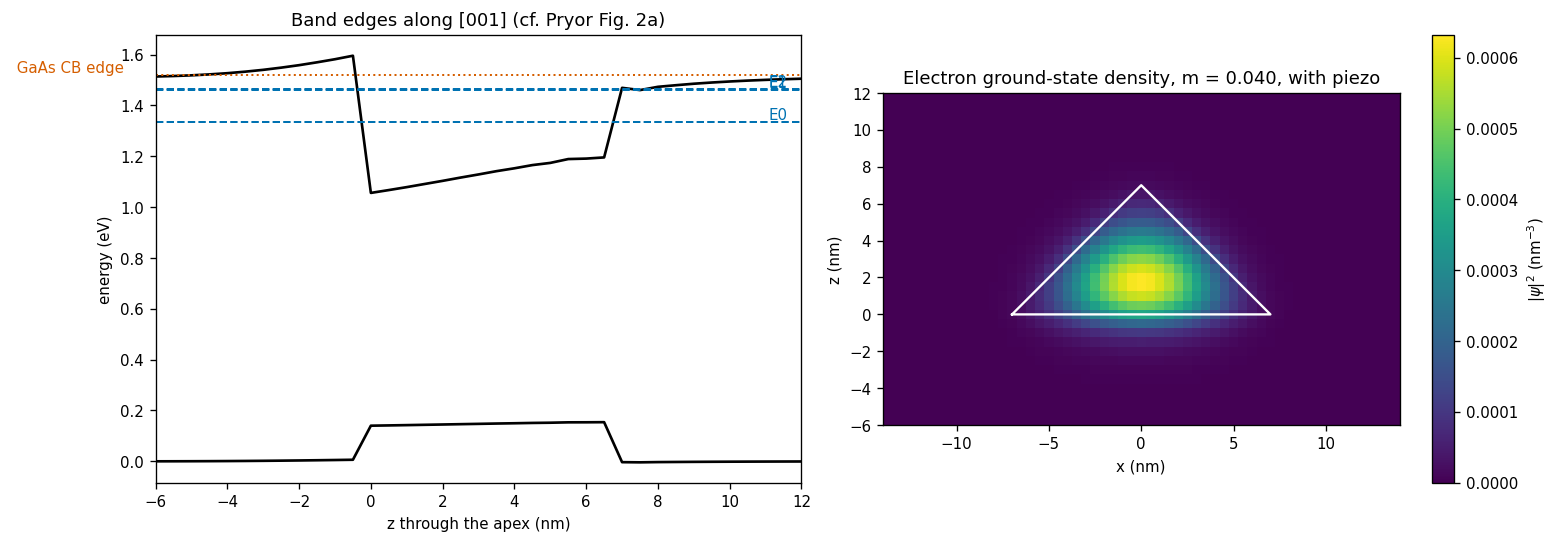

In [4]:
r = results[('strain_averaged', True)]
Nx, Ny, Nz = X.shape
mid = Nx // 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.plot(cz, r['V_e'][mid, mid, :], color='black', lw=1.6)
ax.plot(cz, r['V_h'][mid, mid, :], color='black', lw=1.6)
for i, E in enumerate(r['E'][:3]):
    if E < GAAS_CB:
        ax.axhline(E, color='#0072B2', ls='--', lw=1.2)
        ax.text(11.6, E, f'E{i}', color='#0072B2', va='bottom', ha='right', fontsize=9)
ax.axhline(GAAS_CB, color='#D55E00', ls=':', lw=1.2)
ax.text(cz[0], GAAS_CB, ' GaAs CB edge', color='#D55E00', va='bottom', fontsize=9)
ax.set_xlabel('z through the apex (nm)'); ax.set_ylabel('energy (eV)')
ax.set_title('Band edges along [001] (cf. Pryor Fig. 2a)')
ax.set_xlim(-6, 12)

ax = axes[1]
dens = (r['psi'][:, 0]**2).reshape(X.shape)[:, mid, :]
im = ax.pcolormesh(cx, cz, dens.T, shading='auto', cmap='viridis')
ax.plot([-base/2, 0, base/2, -base/2], [0, base/2, 0, 0], color='white', lw=1.4)
ax.set_xlabel('x (nm)'); ax.set_ylabel('z (nm)'); ax.set_aspect('equal')
ax.set_title('Electron ground-state density, m = 0.040, with piezo')
ax.set_xlim(-14, 14); ax.set_ylim(-6, 12)
fig.colorbar(im, ax=ax, label=r'$|\psi|^2$ (nm$^{-3}$)')
plt.tight_layout(); plt.show()

### The piezoelectric potential, and what it does to the $p$ states

$\varepsilon_{xy}$ changes sign under a 90° rotation while the pyramid does not, so $\phi$ is
**odd** under that rotation — the four-lobe pattern. Signed field, so a diverging map with a
neutral midpoint.

The bottom row is the payoff, but it needs reading carefully. Without piezoelectricity the two
$p$ states are **exactly degenerate**, so any linear combination of them is equally an
eigenvector and the orientation the solver happens to return is arbitrary — which is why the
"no piezo" lobes below already sit on a diagonal. Nothing physical picks a direction there.
Switching the piezoelectric field on lifts the degeneracy, and only then does the orientation
mean something: the two states align along $[110]$ and $[1\bar10]$, split by a few meV.

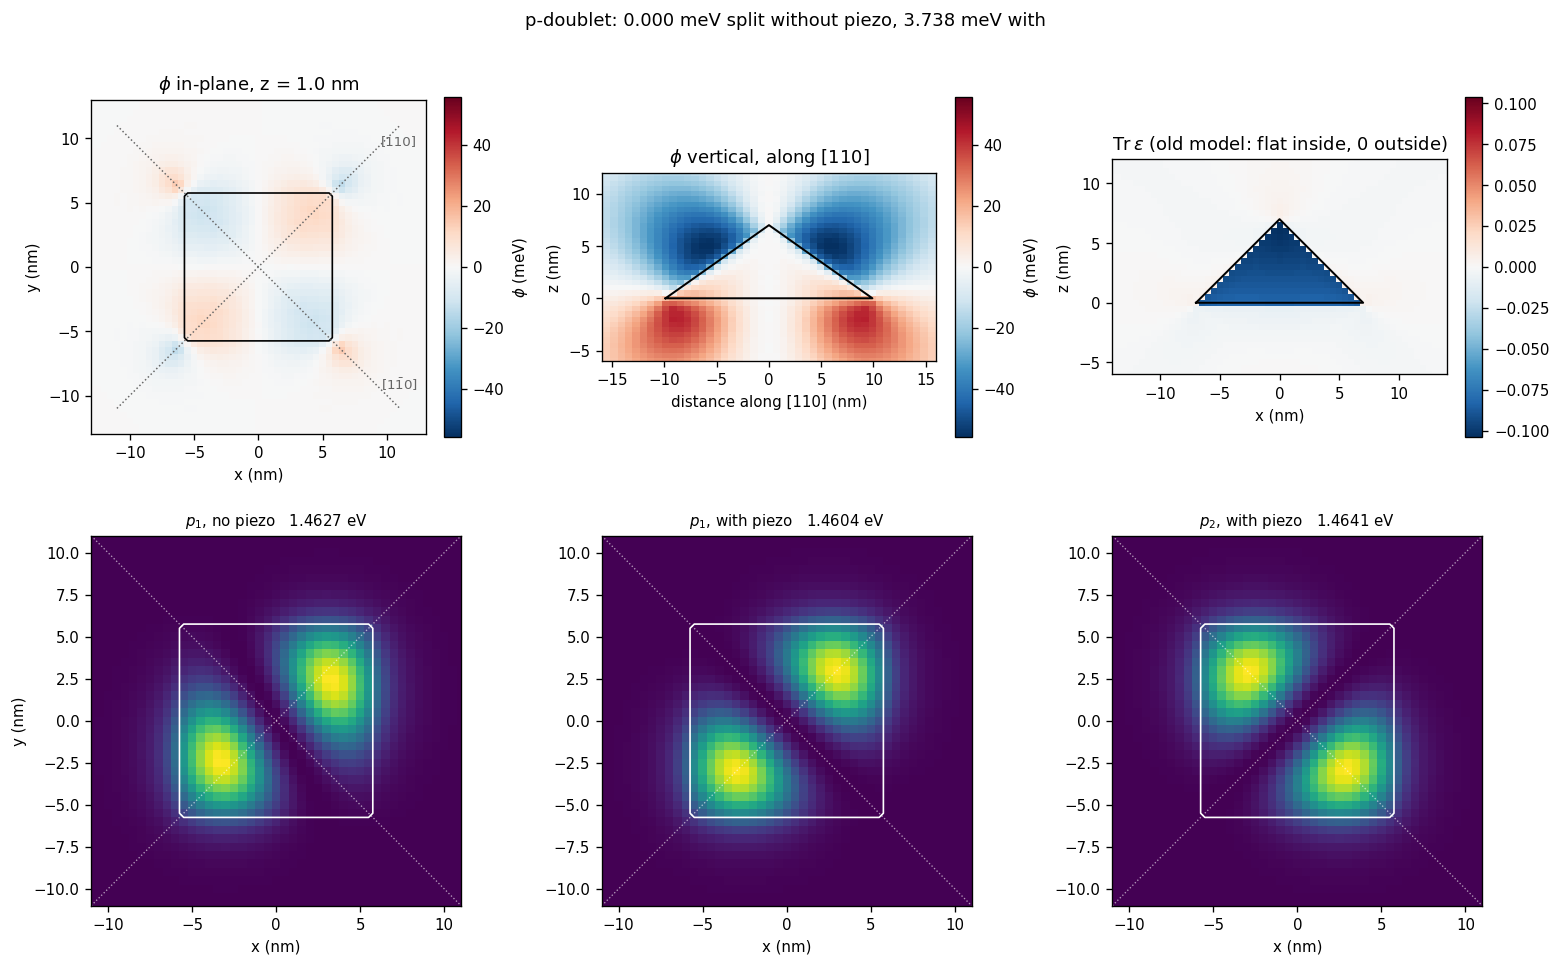

In [5]:
zi = int(np.argmin(np.abs(cz - 1.0)))
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

ax = axes[0, 0]
v = np.abs(phi).max() * 1e3
im = ax.pcolormesh(cx, cx, phi[:, :, zi].T * 1e3, shading='auto', cmap='RdBu_r',
                   norm=TwoSlopeNorm(0.0, -v, v))
ax.contour(cx, cx, inside[:, :, zi].T.astype(float), levels=[0.5], colors='black',
           linewidths=1.0)
for sgn, lbl in ((1, '[110]'), (-1, r'[1$\bar{1}$0]')):
    ax.plot([-11, 11], [-11 * sgn, 11 * sgn], color='0.4', lw=0.9, ls=':')
    ax.text(9.5, 9.5 * sgn, lbl, color='0.4', fontsize=8)
ax.set_title(f'$\\phi$ in-plane, z = {cz[zi]:.1f} nm'); ax.set_aspect('equal')
ax.set_xlabel('x (nm)'); ax.set_ylabel('y (nm)'); ax.set_xlim(-13, 13); ax.set_ylim(-13, 13)
fig.colorbar(im, ax=ax, label='$\\phi$ (meV)', fraction=0.046)

ax = axes[0, 1]
# phi is IDENTICALLY ZERO on the y = 0 plane: that plane is a mirror of the pyramid and
# eps_xy is odd across it, so P_z vanishes there. The informative vertical cut is along
# [110], where the quadrupole lobes actually live.
diag = np.array([phi[i, i, :] for i in range(len(cx))])
s110 = cx * np.sqrt(2.0)
im = ax.pcolormesh(s110, cz, diag.T * 1e3, shading='auto', cmap='RdBu_r',
                   norm=TwoSlopeNorm(0.0, -v, v))
ax.plot([-base/np.sqrt(2), 0, base/np.sqrt(2), -base/np.sqrt(2)],
        [0, base/2, 0, 0], color='black', lw=1.2)
ax.set_title('$\\phi$ vertical, along [110]'); ax.set_aspect('equal')
ax.set_xlabel('distance along [110] (nm)'); ax.set_ylabel('z (nm)')
ax.set_xlim(-16, 16); ax.set_ylim(-6, 12)
fig.colorbar(im, ax=ax, label='$\\phi$ (meV)', fraction=0.046)

ax = axes[0, 2]
tr_sl = trace_strain[:, mid, :].T
vt = np.abs(tr_sl).max()
im = ax.pcolormesh(cx, cz, tr_sl, shading='auto', cmap='RdBu_r',
                   norm=TwoSlopeNorm(0.0, -vt, vt))
ax.plot([-base/2, 0, base/2, -base/2], [0, base/2, 0, 0], color='black', lw=1.2)
ax.set_title(r'$\mathrm{Tr}\,\varepsilon$ (old model: flat inside, 0 outside)')
ax.set_aspect('equal'); ax.set_xlabel('x (nm)'); ax.set_ylabel('z (nm)')
ax.set_xlim(-14, 14); ax.set_ylim(-6, 12)
fig.colorbar(im, ax=ax, fraction=0.046)

for idx, (piezo, k) in enumerate([(False, 1), (True, 1), (True, 2)]):
    ax = axes[1, idx]
    rr = results[('strain_averaged', piezo)]
    d = (rr['psi'][:, k]**2).reshape(X.shape)[:, :, zi]
    ax.pcolormesh(cx, cx, d.T, shading='auto', cmap='viridis')
    ax.contour(cx, cx, inside[:, :, zi].T.astype(float), levels=[0.5], colors='white',
               linewidths=1.0)
    for sgn in (1, -1):
        ax.plot([-11, 11], [-11 * sgn, 11 * sgn], color='white', lw=0.8, ls=':', alpha=0.6)
    ax.set_aspect('equal'); ax.set_xlim(-11, 11); ax.set_ylim(-11, 11)
    ax.set_xlabel('x (nm)')
    if idx == 0:
        ax.set_ylabel('y (nm)')
    ax.set_title(f"$p_{k}$, {'with' if piezo else 'no'} piezo   "
                 f"{rr['E'][k]:.4f} eV", fontsize=9)
sp0 = abs(results[('strain_averaged', False)]['E'][2]
          - results[('strain_averaged', False)]['E'][1]) * 1e3
sp1 = abs(results[('strain_averaged', True)]['E'][2]
          - results[('strain_averaged', True)]['E'][1]) * 1e3
fig.suptitle(f'p-doublet: {sp0:.3f} meV split without piezo, {sp1:.3f} meV with', y=1.0)
plt.tight_layout(); plt.show()

## 3. Against Pryor

The row that matters is the last one. `pryor_benchmark.ipynb` could only assert that the
splitting *ought* to be zero without piezoelectricity and 2-6 meV with it; both halves now check
out, and the measured value lands inside Pryor's range.

In [6]:
B = pr.BENCHMARK_B14
E_un = results[('unstrained', True)]['E']
E_sa = results[('strain_averaged', True)]['E']

print(f"{'quantity':<40}{'Pryor':>10}{'ours':>10}{'diff':>10}")
print('-' * 70)
def row(label, pryor, ours, scale=1.0):
    print(f"{label:<40}{pryor*scale:>10.3f}{ours*scale:>10.3f}{(ours-pryor)*scale:>+10.3f}")

row('E0, m = 0.023 (eV)', B['E0_unstrained_mass'], E_un[0])
row('E0, m = 0.040 (eV)',
    B['E0_unstrained_mass'] - B['extra_binding_strain_averaged'], E_sa[0])
row('extra binding 0.023->0.040 (meV)',
    B['extra_binding_strain_averaged'], E_un[0] - E_sa[0], scale=1e3)
row('E1 - E0 at m = 0.040 (meV)',
    B['E1_minus_E0_strain_averaged'], E_sa[1] - E_sa[0], scale=1e3)
print(f"{'bound states at m = 0.023':<40}{B['n_bound_unstrained_mass']:>10}"
      f"{int(np.sum(E_un < GAAS_CB)):>10}")
print()
print(f"p_x/p_y splitting at m = 0.040:")
print(f"   without piezo  {sp0:.3f} meV   (must be exactly 0 by C4 symmetry)")
print(f"   with piezo     {sp1:.3f} meV   (Pryor: 2-6 meV)")

quantity                                     Pryor      ours      diff
----------------------------------------------------------------------
E0, m = 0.023 (eV)                           1.410     1.368    -0.042
E0, m = 0.040 (eV)                           1.380     1.335    -0.045
extra binding 0.023->0.040 (meV)            30.000    33.426    +3.426
E1 - E0 at m = 0.040 (meV)                 110.000   125.747   +15.747
bound states at m = 0.023                        1         3

p_x/p_y splitting at m = 0.040:
   without piezo  0.000 meV   (must be exactly 0 by C4 symmetry)
   with piezo     3.738 meV   (Pryor: 2-6 meV)


## What changed, and what did not

**Confirmed.** The piezoelectric splitting is 2-4 meV, inside the 2-6 meV range the old notebook
quoted from Pryor, and it is exactly 0.000 meV without the piezoelectric field. The old notebook
reported 0.0006 meV for that "zero" — small, but nonzero *for the wrong reason*: it was the
lopsided h = 0.7 grid, not physics.

**Got worse, honestly.** The electron is now over-bound rather than under-bound. The old notebook
under-bound by 20-27 meV and attributed it to the flat 297 meV well versus Pryor's 400 meV base;
with the corrected trace the well is ~426 meV mean and tapered, and the ground state binds ~150
meV against Pryor's ~110, with three bound states where he reports one. So the old notebook's
closing explanation was the right shape but the wrong sign, and the discrepancy is not the
geometry, not the well depth, and not piezoelectricity — which moves $E_0$ by 0.2 meV.

Remaining candidates, none yet tested: the homogeneous-elastic-constant approximation (though
GaAs constants already give the shallowest well of the three choices), second-order
piezoelectricity, and the precision of the Fig. 7a values being compared against.